# Training

In [1]:
from ddsp import DDSP, AudioDataset
from ddsp.callbacks import BetaWarmupEpochCallback
from ddsp.synths import NoiseBandSynth, SineSynth, SubbandSineSynth
from ddsp.utils import find_checkpoint

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

from IPython.display import Audio, display

from torch.utils.data import DataLoader, Subset, random_split

import torch
import umap

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')


import os

experiment_root = '/home/btadeusz/code/ddsp_vae/experiments/wasserstein_loss/'
training_root = os.path.join(experiment_root, 'training')

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [ ]:
# Dataset parameters
chunk_duration = 2.0
sampling_rate = 44100
n_signal = chunk_duration * sampling_rate
batch_size = 16

# Model parameters
latent_size = num_params = 4
n_sines = 1

# Training parameters
# warmup_start = 300
# warmup_end = 500
# beta = 1.0
max_epochs = 5000
learning_rate = 1e-6


In [ ]:
def get_dataset_split(dataset_path, validation_split=0.2):
  """
  Splits the dataset into training and validation sets.
  """
  generator = torch.Generator(device='cuda')

  dataset_A = AudioDataset(dataset_path=dataset_path, n_signal=n_signal)
  total_len = len(dataset_A)

  val_len = int(validation_split * total_len)  # 20% for validation
  indices = torch.randperm(total_len, generator=generator)

  val_indices = indices[:val_len]
  train_indices = indices[val_len:]

  train_set = Subset(dataset_A, train_indices)
  val_set = Subset(dataset_A, val_indices)

  train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=0, generator=generator)
  val_loader = DataLoader(val_set, batch_size, shuffle=False, num_workers=0, generator=generator)

  return train_loader, val_loader

def examine_model(model, val_loader):
  """
  Examines the trained model by displaying original and autoencoded audio samples,
  as well as reporting on the loss.
  """
  model = model.cuda()
  model.eval()
  with torch.no_grad():
    x_audio = next(iter(val_loader))
    x_audio = x_audio.to('cuda')

    # Forward pass through the model
    y_audio = model(x_audio).squeeze(1)

    print(x_audio.shape, y_audio.shape)

    # Display original and reconstructed audio
    for j in range(x_audio.shape[0]):
      print(f"Sample {j + 1}:")
      x_audio_j = x_audio[j].cpu()
      y_audio_j = y_audio[j].cpu()

      display(Audio(x_audio_j.numpy(), rate=sampling_rate))
      display(Audio(y_audio_j.numpy(), rate=sampling_rate))


In [ ]:
sines = SineSynth.to_config(fs=sampling_rate, n_sines=n_sines)

ckpt = os.path.join(training_root, 'last.ckpt')

# ddsp = DDSP.load_from_checkpoint(ckpt, learning_rate=1e-5, plateau_patience=1000).to('cuda')
ddsp = DDSP(
  synth_configs=[sines],
  fs=sampling_rate,
  latent_size=latent_size,
  num_params=num_params,
  learning_rate=learning_rate,
  perceptual_loss_weight=0,
  plateau_patience=1000,
  n_melbands=512,
).to('cuda')

best_checkpoint_callback = ModelCheckpoint(
  filename='best',
  monitor='val_loss',
  mode='min',
  save_top_k=1,
  save_last=True,
  dirpath=training_root,
)

trainer = Trainer(
  callbacks = [best_checkpoint_callback],
  max_epochs=max_epochs,
  accelerator='cuda',
  precision=16
)


# train_loader, val_loader = get_dataset_split('/mnt/mariadata/datasets/syntex/am_and_chirps/DS_BasicAM_1.1/audio')
# train_loader, val_loader = get_dataset_split('/mnt/mariadata/datasets/syntex/am_and_chirps/BasicSines/audio')
train_loader, val_loader = get_dataset_split('/mnt/mariadata/datasets/syntex/am_and_chirps/SingleSine/audio')
trainer.fit(
    model=ddsp,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    # ckpt_path=ckpt
)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style()

x_audio = next(iter(val_loader))
x_audio = x_audio.to('cuda')
print(f'x audio shape: {x_audio.shape}')

# Forward pass through the model
latents, _ = ddsp.encoder(x_audio)
synth_params = ddsp.decoder(latents)
print(f'synth params shape: {synth_params.shape}')

amplitudes = synth_params[:, :n_sines]
frequencies = synth_params[:, n_sines:]

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
axs[0,0].plot(amplitudes[0].squeeze().detach().cpu().numpy())
axs[0,0].set_title('Amplitudes')

# Calculate the 5th and 95th percentiles for the frame indices
num_frames = amplitudes.shape[-1]
lower_idx = int(0.05 * num_frames)
upper_idx = int(0.95 * num_frames)

# Slice to central 90% frames
central_amplitudes = amplitudes[0, 0, lower_idx:upper_idx].detach().cpu().numpy()
central_frequencies = frequencies[0, 0, lower_idx:upper_idx].detach().cpu().numpy()

# central_frequencies = central_frequencies * ddsp.fs/4
axs[0,1].plot(central_frequencies)
axs[0,1].set_title('Frequencies (central 90% frames)')

axs[1,0].plot(latents[0].squeeze().detach().cpu().numpy())
axs[1,0].set_title('Latents')

plt.show()


In [ ]:
examine_model(ddsp, val_loader)

# Implementing the loss

## Generate audio and display spectrograms

In [ ]:
import torch
from torch import nn
import numpy as np
import math
from IPython.display import Audio, display

import matplotlib.pyplot as plt
import seaborn as sns


fs = 8000
dur = 2 # seconds
n_samples = fs*dur
f1 = 2000
f2 = 1000
f3 = 100

x = torch.sin(torch.arange(n_samples)/fs*f1*2*np.pi)
y = torch.sin(torch.arange(n_samples)/fs*f1*2*np.pi)
# y += 0.3*torch.sin(torch.arange(n_samples)/fs*f3*2*np.pi)
y += 0.5*torch.randn(n_samples)

win_size = 256

display(Audio(x.detach().numpy(), rate=fs))

window = torch.hann_window(win_size)
X = torch.stft(x, n_fft=win_size, window=window, return_complex=True)
Y = torch.stft(y, n_fft=win_size, window=window, return_complex=True)

X_mag = torch.log(X.abs())
Y_mag = torch.log(Y.abs())
X = X / (X.sum() + 1e-8)
Y = Y / (Y.sum() + 1e-8)

F, T = X_mag.shape

tlabels = np.linspace(0, dur, T)
flabels = np.linspace(0, fs//2, F)

sns.set_theme()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].pcolormesh(tlabels, flabels, X_mag, shading='auto', cmap='plasma')
axs[1].pcolormesh(tlabels, flabels, Y_mag, shading='auto', cmap='plasma')
fig.tight_layout()

plt.show()


# Comparing losses

In [8]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as func
from ot import wasserstein_1d
import scipy

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

win_size=2048
hop_size=512
eps=1e-8
n_projections=10
k=1e1

def stft(x: torch.Tensor) -> torch.Tensor:
    """
    Compute the Short-Time Fourier Transform (STFT) of the input signal.

    Args:
      - x: torch.Tensor, the input audio signal

    Returns:
      - X: torch.Tensor, the magnitude spectrum of the STFT
    """
    # window = torch.hann_window(win_size)
    window = scipy.signal.windows.flattop(win_size, sym=False)  # sym=False for FFT use
    window = torch.from_numpy(window).to(device='cuda', dtype=torch.float32)
    x_stft = torch.stft(x, n_fft=win_size, hop_length=hop_size, window=window, return_complex=True)
    x_mag = torch.sqrt(torch.clamp(x_stft.real**2 + x_stft.imag**2, min=eps))
    x_mag = torch.log1p(x_mag)
    return x_mag


def wasserstein_loss_pot(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Compute the Sliced Wasserstein loss between two audio signals.

    Args:
      - x: torch.Tensor[B, N], the first audio signal
      - y: torch.Tensor[B, N], the second audio signal

    Returns:
      - loss: torch.Tensor, the computed Sliced Wasserstein loss
    """
    # Ensure the input tensors are the same shape
    if x.shape != y.shape:
      raise ValueError("Input tensors must have the same shape.")

    X_mag = stft(x).permute(1, 0)  # shape: [T, F]
    Y_mag = stft(y).permute(1, 0)  # shape: [T, F]

    # TODO: Make sure that this is necessary & correct
    # X_mag = X_mag / (X_mag.sum() + eps)
    # Y_mag = Y_mag / (Y_mag.sum() + eps)
    X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
    Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

    T, F = X_mag.shape

    time_bins = torch.linspace(0, 1, T)
    freq_bins = torch.linspace(0, 1, F)
    t_coords, f_coords = torch.meshgrid([time_bins, freq_bins], indexing='ij')

    thetas = torch.arange(0, n_projections) * 2 * torch.pi / n_projections
    diffs = []
    for theta in thetas:
      projected_coords = t_coords*torch.cos(theta)*math.sqrt(k) + f_coords*torch.sin(theta)
      coords_vec = projected_coords.flatten()
      X_vec = X_mag.flatten()
      Y_vec = Y_mag.flatten()

      # print(X_vec.shape, Y_vec.shape, coords_vec.shape)

      diff = wasserstein_1d(coords_vec, coords_vec, X_vec, Y_vec, p=2, require_sort=True)
      diffs.append(diff)

    loss = torch.vstack(diffs).sum()/len(diffs)
    return loss


def wasserstein_loss_manual(x, y):
  X_mag = stft(x).permute(1, 0)  # shape: [T, F]
  Y_mag = stft(y).permute(1, 0)  # shape: [T, F]

  # X_mag = X_mag / (X_mag.sum() + eps)
  # Y_mag = Y_mag / (Y_mag.sum() + eps)
  X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
  Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

  T, F = X_mag.shape

  freq_bins = torch.linspace(0, F-1, F)
  time_bins = torch.linspace(0, T-1, T)

  t_coords, f_coords = torch.meshgrid([time_bins, freq_bins], indexing='ij') # shape: [T, F]

  thetas = torch.linspace(0, 2*math.pi, n_projections+1)[:-1]
  diffs = []
  for theta in thetas:
    coords = torch.cos(theta) * math.sqrt(k) * t_coords  + torch.sin(theta) * f_coords

    # Flatten everything
    coords = coords.flatten()
    X_mag = X_mag.flatten()
    Y_mag = Y_mag.flatten()

    # Sort
    sorted_idx = torch.argsort(coords)

    # coords_sorted = coords[sorted_idx]
    X_mag_sorted = X_mag[sorted_idx]
    Y_mag_sorted = Y_mag[sorted_idx]

    # cumulative density functions
    x_cdf = torch.cumsum(X_mag_sorted, 0)
    y_cdf = torch.cumsum(Y_mag_sorted, 0)

    diff = torch.pow(x_cdf - y_cdf, 2).sum()
    diffs.append(diff)

  return torch.stack(diffs).sum()


def project_sort(x, proj):
  return torch.einsum('fn,fp->pn', x, proj).sort()[0]

from music2latent import EncoderDecoder
from music2latent.audio import to_representation_encoder
def wasserstein_loss_random(x, y):
  X_mag = stft(x)  # shape: [F, T]
  Y_mag = stft(y)  # shape: [F, T]



  # TODO: Make sure that this is necessary & correct
  # X_mag = X_mag / (X_mag.sum() + eps)
  # Y_mag = Y_mag / (Y_mag.sum() + eps)
  X_mag = torch.softmax(X_mag.flatten(), dim=0).reshape(X_mag.shape)
  Y_mag = torch.softmax(Y_mag.flatten(), dim=0).reshape(Y_mag.shape)

  F, T = X_mag.shape

  projs = func.normalize(torch.randn(F, n_projections), dim=0)
  source_proj = project_sort(X_mag, projs)
  target_proj = project_sort(Y_mag, projs)
  # target_interp = F.interpolate(target_proj, n, mode='nearest')
  return (source_proj-target_proj).square().sum()



from auraloss.freq import MultiResolutionSTFTLoss
from ddsp.losses import SlicedWassersteinLoss, M2LLoss, CLAPLoss
from time import time

sample_rate=44100
dur = 2 # seconds
n_samples = sample_rate*dur

fft_sizes = np.array([2053, 1021, 509, 257])
mss = MultiResolutionSTFTLoss(
  fft_sizes=fft_sizes,
  hop_sizes=fft_sizes//4,
  win_lengths=fft_sizes,
  window='flattop_window',
  mag_distance='L2',
)

# fft_sizes=np.array([1024, 512, 256, 128, 64])
# mss = MultiResolutionSTFTLoss(fft_sizes=fft_sizes, hop_sizes=fft_sizes//2, win_lengths=fft_sizes, w_lin_mag=1.0)
mss_loss = lambda x,y: mss(x.reshape(1,1,-1), y.reshape(1,1,-1))

wloss = SlicedWassersteinLoss(win_size=win_size, n_projections=n_projections, p=1, hop_size=hop_size, sampling_rate=sample_rate)
wasserstein_loss_batched = lambda x, y: wloss(x.unsqueeze(0), y.unsqueeze(0))
wloss_2048 = SlicedWassersteinLoss(win_size=2048, n_projections=n_projections, p=2, hop_size=hop_size, sampling_rate=sample_rate)
wasserstein_loss_batched_2048 = lambda x, y: wloss(x.unsqueeze(0), y.unsqueeze(0))

m2l_loss = M2LLoss()
def m2l(x, y):
  with torch.no_grad():
    return m2l_loss(x.reshape(1,1,-1), y.reshape(1,1,-1))

gamma = 10
theta = 0.99
# Combined wasserstein batched + mss
combined_loss = lambda x, y: (wloss(x.unsqueeze(0), y.unsqueeze(0))**theta + gamma * mss(x.reshape(1,1,-1), y.reshape(1,1,-1))) / 2

# clap_loss = CLAPLoss()
# def clap(x, y):
#   with torch.no_grad():
#     return clap_loss(x.reshape(1,1,-1), y.reshape(1,1,-1))

ot_losses = []
mss_losses = []

loss_functions = {
  # 'ot - manual': wasserstein_loss_manual,
  # 'ot - POT': wasserstein_loss_pot,
  'ot - batched - 512': wasserstein_loss_batched,
  # 'ot - batched - 2048': wasserstein_loss_batched_2048,
  # 'ot - random': wasserstein_loss_random,
  'mss': mss_loss,
  # 'm2l': m2l,
  # 'clap': clap,
  f'ot+{gamma:.2f}mss': combined_loss,
}


## Single shifted sinusoid

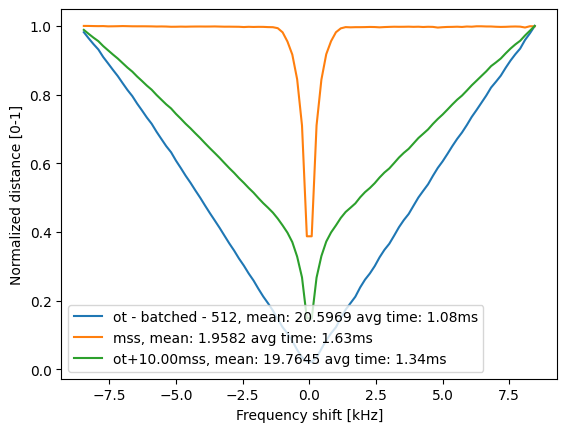

In [4]:
losses = {}
loss_calc_times = {}
for loss_fn_name in loss_functions.keys():
  losses[loss_fn_name] = []
  loss_calc_times[loss_fn_name] = []

base_freq = 10000
shift_lower = -9000
shift_upper = 9000

steps = 100
x = torch.sin(torch.arange(n_samples)/sample_rate * base_freq * 2 * torch.pi)
freq_shifts = torch.linspace(shift_lower, shift_upper, steps)[3:-3]
for freq_shift in freq_shifts:

  y = torch.sin(torch.arange(n_samples)/sample_rate * (base_freq+freq_shift) * 2 * torch.pi)
  for loss_fn_desc, loss_fn in loss_functions.items():
    start_time = time()
    losses[loss_fn_desc].append(loss_fn(x, y))
    loss_calc_times[loss_fn_desc].append(time() - start_time)


for loss_fn_desc in loss_functions.keys():
  cur_losses = torch.vstack(losses[loss_fn_desc])
  cur_loss_mean = cur_losses.mean()
  cur_losses /= (cur_losses.max() + eps)
  cur_loss_avg_calc_time = np.array(loss_calc_times[loss_fn_desc]).mean() * 1000
  plt.plot(freq_shifts.cpu().detach()/1000, cur_losses.cpu().detach(), label=f'{loss_fn_desc}, mean: {cur_loss_mean:.4f} avg time: {cur_loss_avg_calc_time:.2f}ms')


sns.set_style()
plt.ylabel('Normalized distance [0-1]')
plt.xlabel('Frequency shift [kHz]')
plt.legend()
plt.show()

## Two shifted sinusoids

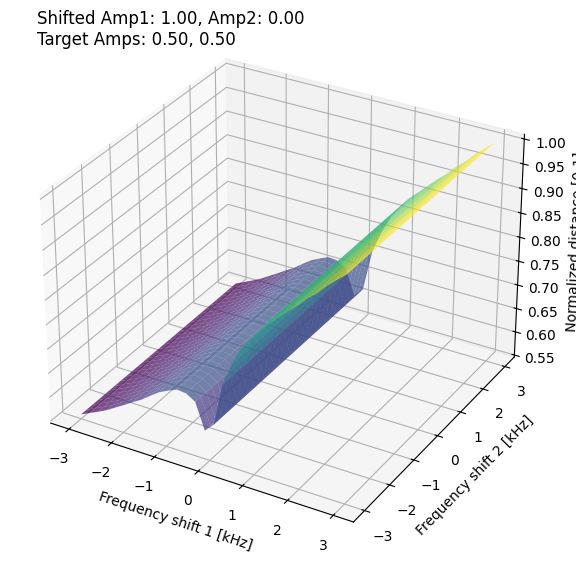

In [14]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation

# Configurable parameters
fs = 44100
amp_steps_n = 60  # Number of steps for amplitude sweep
freq_steps_n = 30
shift = 3000
base_freq_1 = 12000
base_freq_2 = 3000
freq_shifts = torch.linspace(-shift, shift, freq_steps_n)
amp_steps = torch.linspace(0, 1, amp_steps_n)
sample_rate = fs
n_samples = int(sample_rate * dur)

# Prepare meshgrid for frequency shifts
X, Y = torch.meshgrid(freq_shifts.cpu() / 1000, freq_shifts.cpu() / 1000, indexing='ij')

# Prepare amplitude pairs (amp1, amp2) for the shifted sinusoids only
amp_pairs = []
for i in range(amp_steps_n):
  amp1 = amp_steps[i]
  amp2 = 1 - amp1
  amp_pairs.append((amp1.item(), amp2.item()))
mid_idx = amp_steps_n // 2
amp_pairs.insert(mid_idx, (0.5, 0.5))

loss_fn_desc = f'ot+{gamma:.2f}mss'
loss_fn = loss_functions[loss_fn_desc]

# Target always has equal amplitudes
target_amp1 = 0.5
target_amp2 = 0.5

# Precompute all loss landscapes for each amplitude pair
loss_landscapes = []
for amp1, amp2 in amp_pairs:
  x = target_amp1 * torch.sin(torch.arange(n_samples)/sample_rate * base_freq_1 * 2 * torch.pi)
  x += target_amp2 * torch.sin(torch.arange(n_samples)/sample_rate * base_freq_2 * 2 * torch.pi)
  losses = np.zeros((len(freq_shifts), len(freq_shifts)))
  for i, freq_shift_1 in enumerate(freq_shifts):
    for j, freq_shift_2 in enumerate(freq_shifts):
      y = amp1 * torch.sin(torch.arange(n_samples)/sample_rate * (base_freq_1+freq_shift_1) * 2 * torch.pi)
      y += amp2 * torch.sin(torch.arange(n_samples)/sample_rate * (base_freq_2+freq_shift_2) * 2 * torch.pi)
      losses[i, j] = loss_fn(x, y).cpu().detach().item()
  # Normalize
  losses = losses / (losses.max() + 1e-8)
  loss_landscapes.append(losses)

# Animation
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = [None]

def update(frame):
  ax.clear()
  losses = loss_landscapes[frame]
  surf[0] = ax.plot_surface(X.numpy(), Y.numpy(), losses, cmap='viridis', alpha=0.7, edgecolor='none')
  amp1, amp2 = amp_pairs[frame]
  ax.set_xlabel('Frequency shift 1 [kHz]')
  ax.set_ylabel('Frequency shift 2 [kHz]')
  ax.set_zlabel('Normalized distance [0-1]')
  # ax.set_title(f'Shifted Amplitudes: {amp1:.2f}, {amp2:.2f}')
  ax.text2D(0.05, 0.95, f'Shifted Amp1: {amp1:.2f}, Amp2: {amp2:.2f}\nTarget Amps: 0.50, 0.50', transform=ax.transAxes, fontsize=12, color='black')

ani = animation.FuncAnimation(fig, update, frames=len(amp_pairs), interval=400, repeat=True)
ani.save('loss_landscape_animation.mp4', writer='ffmpeg', fps=24)
plt.show()


# Optimizing a sinusoid frequency

In [47]:
import torch
torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

import numpy as np
from ddsp.losses import SlicedWassersteinLoss
from auraloss.freq import MultiResolutionSTFTLoss

from IPython.display import Audio, display
from tqdm.notebook import trange

# Configurable parameters
fs = 44100  # sample rate, can be changed
dur = 2.0   # seconds
n_samples = int(fs * dur)

# Loss
sw = SlicedWassersteinLoss(sampling_rate=fs, n_projections=10, win_size=512, hop_size=256, p=2, magnitude='log')
# fft_sizes=np.array([1024, 512, 256, 128, 64])
# mss = MultiResolutionSTFTLoss(fft_sizes=fft_sizes, hop_sizes=fft_sizes//2, win_lengths=fft_sizes, w_lin_mag=1.0)

fft_sizes = np.array([2053, 1021, 509, 257])
mss = MultiResolutionSTFTLoss(
  fft_sizes=fft_sizes,
  hop_sizes=fft_sizes//4,
  win_lengths=fft_sizes,
  window='flattop_window',
  mag_distance='L2',
)

theta = 0.99
gamma = 10.0

# Training loop parameters
n_steps = 200000
learning_rate = 1e-3

# Randomize base frequency in [0, fs/2]
# target_freq = 6000
# target_freq = torch.rand(1).item() * (fs / 2)
target_freq = 5000

# Target sinusoid
t = torch.arange(n_samples, device='cuda') / fs
target = torch.cos(2 * np.pi * target_freq * t).to('cuda')

print("Target frequency:", target_freq)
display(Audio(target.cpu().numpy(), rate=fs))

# a = torch.nn.Parameter(torch.randn(1, device='cuda'))
a = torch.nn.Parameter(torch.Tensor([0.5]))

optimizer = torch.optim.Adam([a], lr=learning_rate)

losses = []
progress_bar = trange(n_steps, desc="Training", leave=True)
for step in progress_bar:
  optimizer.zero_grad()
  freq = torch.sigmoid(a) * (fs / 2)  # Ensure frequency is in [0, fs/2]
  # freq = a * fs/2
  synth = torch.cos(2 * np.pi * freq * t)

  sw_loss = sw(synth.unsqueeze(0), target.unsqueeze(0))
  mss_loss = mss(synth.unsqueeze(0).unsqueeze(0), target.unsqueeze(0))
  loss = sw_loss**theta + gamma*mss_loss

  if loss.item() < 1e-7:
    progress_bar.n = step + 1
    progress_bar.last_print_n = step + 1
    progress_bar.update(0)
    break

  loss.backward()
  optimizer.step()
  losses.append(loss.item())

  if step % 100 == 0 or step == n_steps - 1:
    progress_bar.set_postfix({"Loss": f"{loss.item():.6f}", "Freq": f"{freq.item():.2f}"})

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Sliced Wasserstein Loss')
plt.title('Training Loss Curve')
plt.show()

print(f"Fitted frequency: {freq.item():.2f} Hz")
print(f"Target frequency: {target_freq:.2f} Hz")

Target frequency: 5000


Training:   0%|          | 0/200000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Optimizing multiple sinusoids

Target frequencies: tensor([  42.8350,   61.5253,   65.6158,  114.4935,  120.8770,  170.6679,
         190.9200,  857.5711,  880.4261, 1030.1597])
Target amplitudes: tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000])


Training:   0%|          | 0/400000 [00:00<?, ?it/s]

[2.6828010e+00 6.7061477e+00 1.6750603e+01 4.1761002e+01 1.0362986e+02
 2.5422903e+02 6.0686542e+02 1.3625913e+03 2.7139492e+03 4.4974121e+03]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Epoch 31701: reducing learning rate of group 0 to 5.0000e-03.
Epoch 41702: reducing learning rate of group 0 to 2.5000e-03.
Epoch 51703: reducing learning rate of group 0 to 1.2500e-03.
Epoch 61704: reducing learning rate of group 0 to 6.2500e-04.
Epoch 71705: reducing learning rate of group 0 to 3.1250e-04.
Epoch 81706: reducing learning rate of group 0 to 1.5625e-04.
Epoch 91707: reducing learning rate of group 0 to 7.8125e-05.
Epoch 101708: reducing learning rate of group 0 to 3.9063e-05.
Epoch 111709: reducing learning rate of group 0 to 1.9531e-05.
Epoch 121710: reducing learning rate of group 0 to 9.7656e-06.
Epoch 131711: reducing learning rate of group 0 to 4.8828e-06.
Epoch 141712: reducing learning rate of group 0 to 2.4414e-06.
Epoch 151713: reducing learning rate of group 0 to 1.2207e-06.
Epo

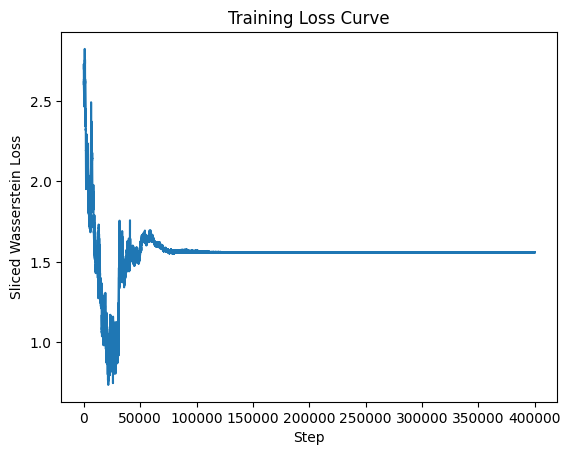

Fitted amps: ['0.10', '0.10', '0.10', '0.10', '0.10', '0.10', '0.10', '0.10', '0.10', '0.10']
Fitted frequencies: ['3.11', '6.39', '15.88', '41.70', '86.59', '124.35', '184.74', '868.16', '1029.58', '4607.63'] Hz
Final loss: 1.559111


In [3]:
import torch
torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

import torch.nn.functional as func

import numpy as np
from ddsp.losses import SlicedWassersteinLoss
from ddsp.synths import SineSynth, SubbandSineSynth
from ddsp.blocks import _scaled_sigmoid

from auraloss.freq import MultiResolutionSTFTLoss

from IPython.display import Audio, display
from tqdm.notebook import trange

# Configurable parameters
fs = 16000  # sample rate, can be changed
dur = 2.0   # seconds
n_samples = int(fs * dur)
target_n_sines = 10

# Loss
sw = SlicedWassersteinLoss(sampling_rate=fs, n_projections=10, win_size=512, hop_size=256, p=2, magnitude='lin')
# fft_sizes=np.array([1024, 512, 256, 128, 64])
# mss = MultiResolutionSTFTLoss(fft_sizes=fft_sizes, hop_sizes=fft_sizes//2, win_lengths=fft_sizes, w_lin_mag=1.0)

fft_sizes = np.array([2053, 1021, 509, 257])
mss = MultiResolutionSTFTLoss(
  fft_sizes=fft_sizes,
  hop_sizes=fft_sizes//4,
  win_lengths=fft_sizes,
  window='flattop_window',
  mag_distance='L2',
)

theta = 0.8
gamma = 1.0

# Training loop parameters
n_steps = int(4e5)
learning_rate = 1e-2
min_learning_rate = 1e-4

def decay_fn(step):
  decay = 0.01 ** (step / n_steps)  # exponential curve
  return max(min_learning_rate / learning_rate, decay)

# Randomize base frequency in [0, fs/2]
# target_freq = 12000
# Less extreme non-linear scaling: interpolate between linear and log-frequency
low_hz = 20
high_hz = fs / 8
alpha = 1.0  # 0=linear, 1=log, 0.5=midway
linear_freqs = torch.empty(target_n_sines).uniform_(low_hz, high_hz)
log_min = np.log(low_hz)
log_max = np.log(high_hz)
log_freqs = torch.exp(torch.empty(target_n_sines).uniform_(log_min, log_max))
target_freqs = (1 - alpha) * linear_freqs + alpha * log_freqs
# target_amps = torch.zeros(target_n_sines).uniform_(0.1, 1.0)
# target_amps /= target_amps.sum()
target_amps = torch.ones(target_n_sines) /  target_n_sines  # Equal amplitudes

# Target signal
t = torch.arange(n_samples, device='cuda') / fs
target = (target_amps * torch.cos(2 * np.pi * target_freqs * t.unsqueeze(1)).to('cuda')).sum(dim=1)

print("Target frequencies:", target_freqs.sort().values)
print("Target amplitudes:", target_amps.sort().values)

# Display the target audio
display(Audio(target.cpu().numpy(), rate=fs))

resampling_factor = 32  # Resampling factor for the sine synthesizer
n_sines = 10
sine_synth = SineSynth(fs=fs, n_sines=n_sines, resampling_factor=resampling_factor, device='cuda')
# sine_synth = SubbandSineSynth(fs=fs, n_sines=n_sines, resampling_factor=resampling_factor, device='cuda')

param_freqs = torch.nn.Parameter(torch.linspace(-8, 1/4, n_sines, device='cuda'))
# param_freqs = torch.nn.Parameter(torch.randn(n_sines, device='cuda'))
param_amps = torch.nn.Parameter(torch.ones(n_sines, device='cuda'))
# a = torch.nn.Parameter(torch.randn(1, device='cuda'))
# b = torch.nn.Parameter(torch.randn(1, device='cuda'))
# a = torch.nn.Parameter(torch.Tensor([0.75]))
# b = torch.nn.Parameter(torch.Tensor([0.5]))

optimizer = torch.optim.Adam([param_freqs, param_amps], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1e4, min_lr=1e-6, verbose=True)
# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=decay_fn)

losses = []
progress_bar = trange(n_steps, desc="Training", leave=True)
i = 0
for step in progress_bar:
  optimizer.zero_grad()
  # Fit the sine wave using the sine synthesizer
  # freqs = _scaled_sigmoid(param_freqs)
  # amps = _scaled_sigmoid(param_amps)
  freqs = torch.sigmoid(param_freqs)
  # amps = torch.sigmoid(param_amps)
  amps = torch.ones(n_sines) * (1 / n_sines)
  freqs_hz = freqs * (fs / 2)  # Scale frequency to [0, fs/2]
  if i == 0:
    print(freqs_hz.cpu().detach().numpy())
    print(amps.cpu().detach().numpy())
  i += 1
  param_samples = n_samples // resampling_factor
  sine_params = torch.concat([freqs, amps]).unsqueeze(1).expand(n_sines*2, param_samples).unsqueeze(0)
  output = sine_synth(sine_params)
  # Make sure output is the same length as target
  output = func.interpolate(output, size=n_samples, mode='linear', align_corners=False)
  sw_loss = sw(output.squeeze(1), target.unsqueeze(0))
  mss_loss = mss(output.reshape(1, 1, -1), target.reshape(1, 1, -1))
  # loss = mss_loss
  loss = sw_loss**theta + gamma * mss_loss



  # print(output.shape, target.reshape(1,1,-1).shape)
  # loss += mss_loss(output, target.reshape(1,1,-1))

  # Fit the sine wave manually
  # freq = torch.sigmoid(a)  # Ensure frequency is in [0, 1]
  # amp = torch.sigmoid(b)
  # freq_hz = freq * (fs / 2)  # Scale frequency to [0, fs/2]
  # synth = amp * torch.cos(2 * np.pi * freq_hz * t)
  # loss = sw_loss(synth.unsqueeze(0), target.unsqueeze(0))
  # loss += 0.5*mss_loss(synth.reshape(1,1,-1), target.reshape(1,1,-1))

  # Break the loop when fitting is done
  # if loss.item() < 1e-7:
  #   progress_bar.n = step + 1
  #   progress_bar.last_print_n = step + 1
  #   progress_bar.update(0)
  #   break

  loss.backward()
  optimizer.step()
  scheduler.step(loss)
  # scheduler.step()
  losses.append(loss.item())

  if step % 100 == 0 or step == n_steps - 1:
    amps_freqs = torch.stack([amps, freqs_hz], dim=1)
    amps_freqs = amps_freqs[amps_freqs[:, 0].argsort(descending=True)]
    # amps_freqs = amps_freqs.sort(dim=1)[0]

    print_amps_freqs = [f'{amp:.2f}*{freq:.2f} Hz' for amp, freq in amps_freqs.cpu().detach().numpy()]
    # print_amps = [f'{amp:.2f}' for amp in amps.sort().values]
    # print_freqs = [f'{freq:.2f}' for freq in freqs_hz.sort().values]
    progress_bar.set_postfix({"Loss": f"{loss.item():.6f}", "Components": f"{print_amps_freqs}", "LR": f"{optimizer.param_groups[0]['lr']:.6f}"})

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Sliced Wasserstein Loss')
plt.title('Training Loss Curve')
plt.show()

print_amps = [f'{amp:.2f}' for amp in amps.sort().values]
print_freqs = [f'{freq:.2f}' for freq in freqs_hz.sort().values]
print(f"Fitted amps: {print_amps}")
print(f"Fitted frequencies: {print_freqs} Hz")
print(f"Final loss: {losses[-1]:.6f}")
display(Audio(output.squeeze().detach().cpu().numpy(), rate=fs))


In [ ]:
plt.plot(losses[len(losses)//16:])
plt.xlabel('Step')
plt.ylabel('Sliced Wasserstein Loss')
plt.title('Training Loss Curve')